In [287]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import make_scorer


In [288]:
def build_prediction_report(X_test, y_pred, lookup_test,
                              dummy_prefix_defaults,
                              log_transformed=True):
    """
    Reconstructs X_test back to its pre-dummy-variable form, attaches
    identifying/lookup columns (price, Make, Model, MoreInformation_x, Year),
    and adds model predictions + error columns for EDA.

    Parameters
    ----------
    X_test : pandas.DataFrame
        The test feature set used for prediction (with dummy columns).
    y_pred : array-like
        Model's predicted values (same scale the model was trained on).
    lookup_test : pandas.DataFrame
        Held-out columns (e.g. price, Make, Model, MoreInformation_x, Year),
        same index as X_test.
    dummy_prefix_defaults : dict
        Maps each dummy-encoded column prefix to its dropped baseline
        category, e.g. {"Cylinders": "4", "Body Type": "Sedan",
        "Country_of_Origin": "USA"}.
    log_transformed : bool, default True
        If True, assumes y_pred (and lookup_test's "price", if present in
        log form) needs expm1 applied to get back to real dollar values.

    Returns
    -------
    pandas.DataFrame: X_test's original (pre-dummy) columns + lookup columns
    + predicted_price + error columns.
    """
    X_test_copy = X_test.copy()

    # --- Figure out which columns are dummy columns vs. columns to keep as-is ---
    all_dummy_cols = []
    reconstructed = {}

    for prefix, default_category in dummy_prefix_defaults.items():
        dummy_cols = [col for col in X_test_copy.columns if col.startswith(prefix + "_")]
        if not dummy_cols:
            print(f"Warning: no dummy columns found for prefix '{prefix}' — skipping.")
            continue
        new_col_name = prefix.replace(" ", "_")
        reconstructed[new_col_name] = pd.from_dummies(
            X_test_copy[dummy_cols], sep="_", default_category=default_category
        )
        all_dummy_cols.extend(dummy_cols)

    # --- Keep every X_test column that wasn't part of a dummy group, untouched ---
    passthrough_cols = [col for col in X_test_copy.columns if col not in all_dummy_cols]
    results = X_test_copy[passthrough_cols].copy()

    # --- Add the reconstructed categorical columns back in ---
    for col_name, series in reconstructed.items():
        results[col_name] = series

    # --- Attach identifying/lookup columns (price, Make, Model, MoreInformation_x, Year) ---
    results = results.join(lookup_test)

    # --- Add predictions and error columns ---
    results["y_pred"] = np.array(y_pred)

    if log_transformed:
        results["predicted_price"] = np.expm1(results["y_pred"])
    else:
        results["predicted_price"] = results["y_pred"]

    # if "price" came from lookup_test, use it directly as the actual value
    if "price" in results.columns:
        results["error"] = results["price"] - results["predicted_price"]
        results["abs_error"] = results["error"].abs()
        results["pct_error"] = (results["error"] / results["price"] * 100).round(2)

    return results

In [289]:
def reverse_dummy_columns(df, prefix_defaults, drop_dummies=True):
    """
    Reverses one-hot/dummy-encoded columns back into single categorical columns.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the dummy columns.
    prefix_defaults : dict
        Maps each original column prefix to its dropped baseline category.
        e.g. {"Cylinders": "4", "Body Type": "Sedan", "Country_of_Origin": "USA"}
    drop_dummies : bool, default True
        If True, removes the original dummy columns after reconstructing
        the categorical column.

    Returns
    -------
    pandas.DataFrame (same object, modified in place and returned for chaining)
    """
    for prefix, default_category in prefix_defaults.items():
        dummy_cols = [col for col in df.columns if col.startswith(prefix + "_")]

        if not dummy_cols:
            print(f"Warning: no dummy columns found for prefix '{prefix}' — skipping.")
            continue

        dummies_subset = df[dummy_cols]
        new_col_name = prefix.replace(" ", "_")
        df[new_col_name] = pd.from_dummies(dummies_subset, sep="_", default_category=default_category)

        if drop_dummies:
            df = df.drop(columns=dummy_cols)

    return df

#TreeModel = reverse_dummy_columns(TreeModel, {
#    "Cylinders": "baseline_value_here",
#    "Body Type": "baseline_value_here",
#    "Country_of_Origin": "baseline_value_here"
#})

In [290]:
results_list = []
def returning_Result(y_train, y_train_pred,y_test,y_pred,NameofTheModel,exponentioal):
    if (exponentioal == True):
        y_train = np.exp(np.ravel(y_train))
        y_train_pred = np.exp(np.ravel(y_train_pred))
        y_test = np.exp(np.ravel(y_test))
        y_pred = np.exp(np.ravel(y_pred))
    else:
        y_train = (np.ravel(y_train))
        y_train_pred = (np.ravel(y_train_pred))
        y_test = (np.ravel(y_test))
        y_pred = (np.ravel(y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    train_r2   = r2_score(y_train, y_train_pred)
    r2_gap = train_r2 - r2
    if r2_gap > 0.1:
        status = "Overfitting"
    elif r2 < 0.5:
        status = "Underfitting"
    else:
        status = "Good Fit"
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2   = r2_score(y_train, y_train_pred)
    return {
        "NameOfModel": NameofTheModel,
        "MAPE" : np.mean(np.abs((np.ravel(y_test) - np.ravel(y_pred)) / y_test)) * 100, #Percentage Error
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R^2": r2,
        "Train_R^2": train_r2,
        "Train_RMSE": train_rmse,
        "R2_Gap": r2_gap,
        "Status": status
    }

In [291]:
TreeModel = pd.read_csv("ModelInput/TreeInput.csv")
TreeModel.drop(columns=["Unnamed: 0"],inplace=True)

In [292]:
#TreeModel["log_price"] = np.log1p(TreeModel["price"])
#TreeModel["log_mileage"] = np.log1p(TreeModel["mileage"])

In [293]:
TreeModel.drop(TreeModel[TreeModel["Condition"]=="New"].index,inplace=True)
TreeModel.drop(columns=["Condition"],inplace = True)
#I will drop the columns with Make == Land - Rover.
TreeModel = TreeModel[(TreeModel["Make"] != "Land")]
TreeModel = TreeModel[(TreeModel["Make"] != "Porsche")]
TreeModel = TreeModel[(TreeModel["Cylinders"] != "Electric")]
#TreeModel.dropna(subset=["Cylinders", "Make"], inplace=True)

In [294]:
#Dummy Variables:
make_for_stratify = TreeModel["Make"].copy()
TreeModel = pd.get_dummies(TreeModel, columns=["transmission","std_tier", "Make","Body Type","Cylinders","Brand_Segment","Country_of_Origin"], drop_first=True)
#TreeModel.loc[TreeModel["Cylinders"] == "Electric", "Cylinders"] = 0
#TreeModel["Cylinders"]=  pd.to_numeric(TreeModel["Cylinders"],errors="coerce")
TreeModel.columns

Index(['Model', 'MoreInformation_x', 'Year', 'price', 'mileage', 'Age',
       'no_accidents', 'has_carfax', 'one_owner', 'service_records',
       'certified', 'Is_Hybrid', 'transmission_Manual', 'std_tier_1std',
       'std_tier_2std', 'std_tier_3std', 'std_tier_Normal', 'Make_Audi',
       'Make_BMW', 'Make_Buick', 'Make_Cadillac', 'Make_Chevrolet',
       'Make_Chrysler', 'Make_Dodge', 'Make_Ford', 'Make_GMC', 'Make_Genesis',
       'Make_Honda', 'Make_Hyundai', 'Make_Infiniti', 'Make_Jeep', 'Make_Kia',
       'Make_Lexus', 'Make_Lincoln', 'Make_MINI', 'Make_Mazda',
       'Make_Mercedes-Benz', 'Make_Mitsubishi', 'Make_Nissan', 'Make_RAM',
       'Make_Subaru', 'Make_Toyota', 'Make_Volkswagen', 'Make_Volvo',
       'Body Type_Coupe', 'Body Type_Hatchback', 'Body Type_Minivan',
       'Body Type_Pickup Truck', 'Body Type_SUV', 'Body Type_Sedan',
       'Body Type_Van', 'Body Type_Wagon', 'Cylinders_3', 'Cylinders_4',
       'Cylinders_5', 'Cylinders_6', 'Cylinders_8', 'Brand_Segment

There is a problem with MoreInformation_X columns. I don't know If I need it or not and it has so many Nan Values.

In [295]:
TreeModel.drop(columns=["MoreInformation_x"],inplace=True)
print(len(TreeModel))

23770


In [296]:
print(TreeModel.isna().sum().sort_values(ascending=False))

Model                    2
Make_MINI                0
Make_Mercedes-Benz       0
Make_Mitsubishi          0
Make_Nissan              0
                        ..
Make_Hyundai             0
Make_Infiniti            0
Make_Jeep                0
Make_Kia                 0
Country_of_Origin_USA    0
Length: 65, dtype: int64


In [297]:
print(len(TreeModel))
lookup_cols = ["Model", "Year"]
# Save them separately, keeping the same index as X
X_lookup = TreeModel[lookup_cols]
# Drop them from your actual training features
TreeModel = TreeModel.drop(columns=lookup_cols)

23770


In [298]:
X = TreeModel.drop(columns=["price"])
y = TreeModel[["price"]]
print(len(X), len(y), len(X_lookup), len(make_for_stratify))
X_train, X_test, y_train, y_test, lookup_train, lookup_test = train_test_split(
    X, y, X_lookup, test_size=0.2, random_state=231,stratify=make_for_stratify
)

23770 23770 23770 23770


In [299]:
print(f"We have this many input variables: {len(X_train.columns)}")

We have this many input variables: 62


In [303]:
#HyperParameter Tunning with Grid Search:
parameter_grid = {
    'max_depth': [2,3,4,5,6,7,8,9,10],
    'learning_rate': [0.1,0.04,0.03,0.05,0.02,0.01],
}

xgb = XGBRegressor(
    n_estimators = 1000,
    subsample=0.8,
    colsample_bytree=1,    # let trees see most columns
    min_child_weight=3,      # mild regularization for the sparse dummies
    reg_lambda=1.0,
    random_state=1,
    n_jobs=-1
)
grid_regressor = GridSearchCV(
    estimator=xgb,
    param_grid=parameter_grid,
    scoring = "neg_root_mean_squared_error",
    n_jobs = -1,
    cv=5,
    refit=True,
    return_train_score=True
)
grid_regressor.fit(X_train, y_train)

y_pred       = grid_regressor.predict(X_test)
y_train_pred = grid_regressor.predict(X_train)

results = pd.DataFrame(grid_regressor.cv_results_)

# Convert negated RMSE back to positive, readable values
results["mean_train_rmse"] = -results["mean_train_score"]
results["mean_test_rmse"] = -results["mean_test_score"]
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Final held-out test RMSE: {test_rmse}")
print(results[["param_max_depth", "param_learning_rate", "mean_train_rmse", "mean_test_rmse"]].sort_values("mean_test_rmse"))


Final held-out test RMSE: 6539.28803464108
    param_max_depth  param_learning_rate  mean_train_rmse  mean_test_rmse
40                6                 0.02      5226.234082     6674.509766
21                5                 0.03      5369.314160     6680.058887
12                5                 0.04      5114.755566     6693.043457
30                5                 0.05      4917.897070     6694.590625
22                6                 0.03      4841.047559     6704.049805
41                7                 0.02      4750.281641     6706.183984
29                4                 0.05      5528.856641     6719.221094
13                6                 0.04      4568.583301     6723.065820
51                8                 0.01      4995.643750     6724.023730
11                4                 0.04      5702.950488     6730.397266
39                5                 0.02      5739.168750     6744.512598
52                9                 0.01      4599.186035     6745.28

In [313]:
#Cross Validatoin:

xgb = XGBRegressor(
    max_depth = 6,
    learning_rate = 0.02,
    n_estimators = 3000,
    subsample=0.8,
    colsample_bytree=1,    # let trees see most columns
    min_child_weight=3,      # mild regularization for the sparse dummies
    reg_lambda=1.0,
    random_state=1,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred       = xgb.predict(X_test)
y_train_pred = xgb.predict(X_train)

results_list.append(returning_Result(y_train, y_train_pred, y_test, y_pred, "XGBoostRegressor",False))

In [314]:
pd.DataFrame(results_list)

,NameOfModel,MAPE,MAE,MSE,RMSE,R^2,Train_R^2,Train_RMSE,R2_Gap,Status
0,Ridge Regression,32.728484,6813.371114,9.738563e+07,9868.415685,0.732327,0.736245,9875.195090,0.003918,Good Fit
1,Ridge Regression,32.726134,6813.327534,9.738273e+07,9868.268632,0.732335,0.736244,9875.198950,0.003910,Good Fit
2,XGBoostRegressor,15.138850,4243.998300,5.055818e+07,7110.427224,0.861036,0.973381,3137.194204,0.112345,Overfitting
3,GradientBoostingRegressor,15.093106,4119.928332,4.403117e+07,6635.598546,0.878976,0.938578,4765.502177,0.059601,Good Fit
4,XGBoostRegressor,14.573770,4040.386485,4.405595e+07,6637.465472,0.878908,0.948536,4362.104994,0.069628,Good Fit


                     feature  importance
49               Cylinders_4    0.131302
53      Brand_Segment_Luxury    0.117977
18             Make_Chrysler    0.046055
1                        Age    0.045878
11             std_tier_3std    0.045175
..                       ...         ...
5            service_records    0.001226
50               Cylinders_5    0.001207
56     Brand_Segment_Premium    0.000000
59  Country_of_Origin_Sweden    0.000000
60      Country_of_Origin_UK    0.000000

[62 rows x 2 columns]


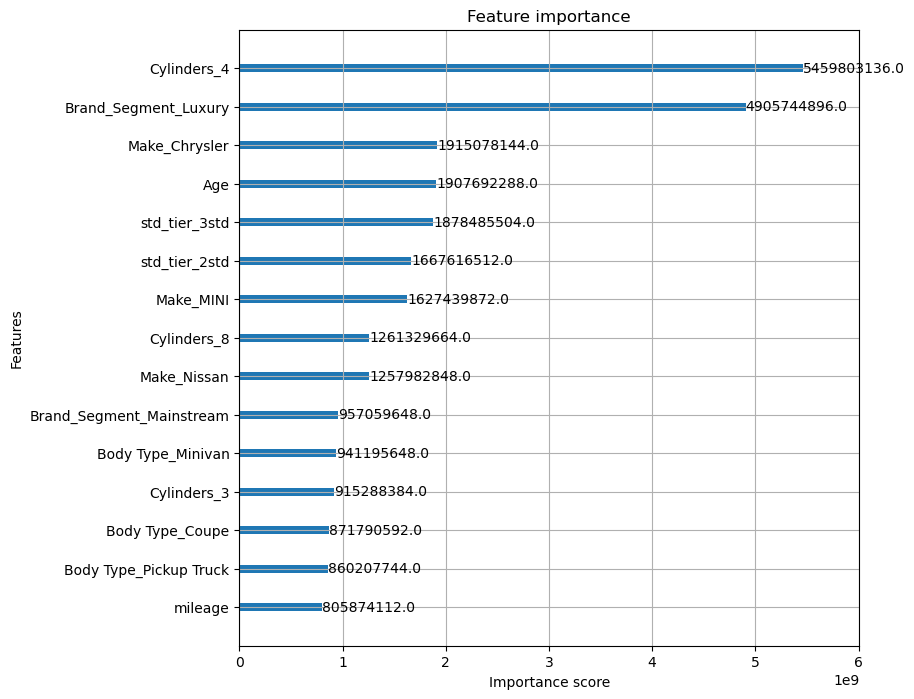

Exception ignored in: <function ResourceTracker.__del__ at 0x1025d1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1031f5c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107f15c60>
Traceback (most recent call last

In [315]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)
from xgboost import plot_importance
print(importances)

fig, ax = plt.subplots(figsize=(8, 8))
plot_importance(xgb, importance_type="gain", max_num_features=15, ax=ax)
plt.show()

In [307]:
report = build_prediction_report(
    X_test=X_test,
    y_pred=y_pred,
    lookup_test=lookup_test,
    dummy_prefix_defaults={
        "Cylinders": "baseline_value_here",
        "Body Type": "baseline_value_here",
        "Country_of_Origin": "baseline_value_here",
        "Make":"baseline_value_here"
    },
    log_transformed=False   # set False if you didn't log-transform price
)

report.to_csv("Model OutPut/ModelOutput.csv")

In [308]:
report = build_prediction_report(
    X_test=X_train,
    y_pred=y_train_pred,
    lookup_test=lookup_train,
    dummy_prefix_defaults={
        "Cylinders": "baseline_value_here",
        "Body Type": "baseline_value_here",
        "Country_of_Origin": "baseline_value_here",
        "Make":"baseline_value_here"
    },
    log_transformed=True   # set False if you didn't log-transform price
)
report.to_csv("Model OutPut/ModelInput.csv")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [309]:
parameter_grid = {
    'max_depth':[3,4],
    'learning_rate':[0.1,0.01],

}
sgbt = GradientBoostingRegressor(
    n_estimators=1000,
    subsample=0.8,
    max_features=0.6,
    random_state=1
)
grid_rgressor_class = GridSearchCV(
    estimator=sgbt,
    param_grid=parameter_grid,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    cv=5,
    refit=True,
    return_train_score=True
)
grid_rgressor_class.fit(X_train, y_train)
y_pred = grid_rgressor_class.predict(X_test)
y_train_pred = grid_rgressor_class.predict(X_train)
results_list.append(returning_Result(y_train,y_train_pred,y_test, y_pred, "GradientBoostingRegressor",False))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y w

In [310]:
pd.DataFrame(results_list)

,NameOfModel,MAPE,MAE,MSE,RMSE,R^2,Train_R^2,Train_RMSE,R2_Gap,Status
0,Ridge Regression,32.728484,6813.371114,9.738563e+07,9868.415685,0.732327,0.736245,9875.195090,0.003918,Good Fit
1,Ridge Regression,32.726134,6813.327534,9.738273e+07,9868.268632,0.732335,0.736244,9875.198950,0.003910,Good Fit
2,XGBoostRegressor,15.138850,4243.998300,5.055818e+07,7110.427224,0.861036,0.973381,3137.194204,0.112345,Overfitting
3,GradientBoostingRegressor,15.093106,4119.928332,4.403117e+07,6635.598546,0.878976,0.938578,4765.502177,0.059601,Good Fit


In [311]:
len(X_train.columns)

62

In [312]:
def error_contribution_table(df, features, error_col="abs_error", sort_by="avg_error_vs_overall_pct"):
    total_error = df[error_col].sum()
    overall_avg_error = df[error_col].mean()

    results = []

    for feature in features:
        for value, group in df.groupby(feature):
            group_error_sum = group[error_col].sum()
            group_avg_error = group[error_col].mean()

            results.append({
                "feature": feature,
                "value": value,
                "count": len(group),
                "total_error_share_pct": round(group_error_sum / total_error * 100, 2),
                "avg_error": round(group_avg_error, 2),
                "avg_error_vs_overall_pct": round((group_avg_error - overall_avg_error) / overall_avg_error * 100, 2),
            })

    return pd.DataFrame(results).sort_values(sort_by, ascending=False).reset_index(drop=True)
report["Age_bin"] = pd.qcut(report["Age"], q=10, duplicates="drop")
report["mileage_bin"] = pd.qcut(report["mileage"], q=10, duplicates="drop")
features_to_check = ["Cylinders", "Make", "Body_Type", "Age_bin"]
contribution_table = error_contribution_table(report, features_to_check)
contribution_table

KeyError: 'abs_error'